# Your first result

This notebook opens the output of the bundled CAMPI example: two real acquisition windows from a mock community, searched against their own compact databases. It shows what a completed run contains, how a peptide reaches a study group, and what a blank cell in the matrix means.

Run the example first (`python examples/campi/run_example.py --out tutorial_data/campi`), or set `FASTALAKE_TUTORIAL_DATA` to a directory that holds it.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Where the bundled examples wrote their outputs. Point this at your own run to reuse the cells.
DATA = Path(os.environ.get("FASTALAKE_TUTORIAL_DATA", "../../tutorial_data")).resolve()
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
pd.set_option("display.width", 140, "display.max_colwidth", 60)
RUN = DATA / "campi"
assert RUN.is_dir(), f"no CAMPI run under {DATA}"
sorted(p.name for p in RUN.iterdir() if not p.name.startswith("_"))

['COMPLETE.json',
 'VALIDATION.json',
 'build_aggregation_engine.log',
 'build_fasta_extractor_v2.log',
 'build_parsimony_engine.log',
 'build_reference_lake.log',
 'check_python_runtime.log',
 'check_sage_version.log',
 'commands.json',
 'create_python_environment.log',
 'install_locked_dependencies.log',
 'install_python_package.log',
 'lake.fasta',
 'lake_stats.txt',
 'run_acquisitions.log',
 'source_headers.tsv',
 'study',
 'workflow']

## The receipt

Every example writes `VALIDATION.json`: the status, the counts it measured, and the checksums of every FASTA that entered a search. The numbers below are the example's own, not a benchmark.

In [2]:
validation = json.loads((RUN / "VALIDATION.json").read_text())
print("status:", validation["status"], "| workflow seconds:", round(validation["workflow_seconds"], 1))
m = validation["measurements"]
funnel = pd.DataFrame(m["samples"]).T.drop(columns=[c for c in ("drawn_sha256", "selected_sha256")])
funnel.insert(0, "evidence_sequences", m["evidence_sequences"])
funnel.insert(0, "reference_sequences", m["reference_sequences"])
funnel

status: passed | workflow seconds: 18.3


,reference_sequences,evidence_sequences,drawn_sequences,selected_sequences,target_psms_spectrum_q_001,canonical_target_peptides_peptide_q_001
S01,29635,538,370,348,758,548
S02,29635,538,316,287,593,426


The reference is reduced in three steps: the pooled evidence lake (sequences that contain any retained de novo peptide from either acquisition), the acquisition's own drawn candidates, and the razor-selected search database. Sage then searches each acquisition against its own selected database.

In [3]:
fig, ax = plt.subplots(figsize=(6, 2.8))
stages = ["reference_sequences", "evidence_sequences", "drawn_sequences", "selected_sequences"]
for i, (sample, row) in enumerate(funnel.iterrows()):
    ax.plot(stages, row[stages].astype(float), marker="o", color=OKABE_ITO[i], label=sample)
ax.set_yscale("log"); ax.set_ylabel("protein sequences (log)"); ax.legend(frameon=False)
ax.set_xticks(range(4)); ax.set_xticklabels(["reference", "evidence lake", "drawn", "razor-selected"])
plt.tight_layout()

## From search results to study groups

`workflow/search/<sample>/results.sage.tsv` holds every peptide-spectrum match. The identification gate the study uses is the peptide-level q-value; the receipt's PSM count is reproduced here from the raw table so the two agree by construction.

In [4]:
psms = pd.read_csv(RUN / "workflow/search/S01/results.sage.tsv", sep="\t")
target = psms[psms["label"] == 1]
print("S01 target PSMs at spectrum_q <= 0.01:", int((target["spectrum_q"] <= 0.01).sum()),
      "| receipt says:", m["samples"]["S01"]["target_psms_spectrum_q_001"])
target[["peptide", "proteins", "num_proteins", "spectrum_q", "peptide_q", "protein_q"]].head(8)

S01 target PSMs at spectrum_q <= 0.01: 758 | receipt says: 758


,peptide,proteins,num_proteins,spectrum_q,peptide_q,protein_q
0,HYAHVDC[+57.0215]PGHADYVK,CAMPI_5a5f751b9dc3f44d0ca0c8df1e5b705d7293c511944a6e0fb0...,3,0.001387,0.002137,0.003525
1,GM[+15.9949]GTC[+57.0215]C[+57.0215]VSGC[+57.0215]GEIK,CAMPI_4ae5c49edac52a6a4c737effb520b824e0670811139a11c01a...,1,0.001387,0.002137,0.003525
2,KSNPNELLDDSKR,CAMPI_a554b3e76d27f4b4b6f01ab359567692dcd49e741788dd3001...,1,0.001387,0.002137,0.003525
3,HSHDQLSVSDKIDR,CAMPI_7c3b8d7c41f810f59caf6176c72d81aca97a3b2f87b4a33eda...,1,0.001387,0.002137,0.003525
4,HYAHVDC[+57.0215]PGHADYVK,CAMPI_5a5f751b9dc3f44d0ca0c8df1e5b705d7293c511944a6e0fb0...,3,0.001387,0.002137,0.003525
5,HYAHVDC[+57.0215]PGHADYVK,CAMPI_5a5f751b9dc3f44d0ca0c8df1e5b705d7293c511944a6e0fb0...,3,0.001387,0.002137,0.003525
6,HYAHVDC[+57.0215]PGHADYVK,CAMPI_5a5f751b9dc3f44d0ca0c8df1e5b705d7293c511944a6e0fb0...,3,0.001387,0.002137,0.003525
7,LNSLKGENESLKR,CAMPI_3175ae76fed48f167caa3191bd5ad56e9e6e134cc720eb5fd7...,1,0.001387,0.002137,0.003525


The study-level tables live in `study/`. `study_group_long.tsv` has one row per acquisition and reporting group with the number of distinct peptides, the number of quantified features and the summed intensity. `study_group_matrix.tsv` is the wide form; a blank cell means no admitted quantified feature, which is not evidence of absence.

In [5]:
long = pd.read_csv(RUN / "study/study_group_long.tsv", sep="\t")
matrix = pd.read_csv(RUN / "study/study_group_matrix.tsv", sep="\t", index_col=0)
print(f"{matrix.shape[0]} study groups x {matrix.shape[1]} acquisitions; "
      f"{int(matrix.isna().sum().sum())} blank cells; "
      f"{int(matrix.notna().all(axis=1).sum())} groups quantified in both")
long.groupby("sample")[["n_peptides", "n_features", "intensity"]].agg(["sum", "median"]).round(1)

447 study groups x 2 acquisitions; 321 blank cells; 126 groups quantified in both


n_peptides        n_features            intensity            
              sum median        sum median           sum      median
sample                                                              
S01           541    1.0        545    1.0  5.430718e+10  55009976.4
S02           422    1.0        424    1.0  3.273877e+10  54599722.9

In [6]:
fig, ax = plt.subplots(figsize=(6, 2.8))
for i, (sample, sub) in enumerate(long.groupby("sample")):
    counts = sub["n_peptides"].clip(upper=8).value_counts().sort_index()
    ax.bar(counts.index + (i - 0.5) * 0.4, counts.values, width=0.4, color=OKABE_ITO[i], label=sample)
ax.set_xlabel("distinct peptides per study group (8 = 8 or more)"); ax.set_ylabel("study groups"); ax.legend(frameon=False)
plt.tight_layout()

## Peptide evidence and ambiguity

`peptide_evidence.tsv.gz` lists, per acquisition and group, every canonical peptide with the proteins Sage reported for it. A peptide reported against several searched sequences stays ambiguous; the group it is assigned to is a reporting representative, not proof of origin.

In [7]:
evidence = pd.read_csv(RUN / "study/peptide_evidence.tsv.gz", sep="\t")
ambiguity = pd.read_csv(RUN / "study/peptide_ambiguity.tsv", sep="\t")
display(ambiguity)
evidence[evidence["n_reported_proteins_study"] > 1][["sample", "canonical_peptide", "reported_proteins", "n_reported_proteins_study"]]

,n_reported_proteins_study,n_canonical_peptides
0,1,814
1,2,3
2,3,2


,sample,canonical_peptide,reported_proteins,n_reported_proteins_study
115,S01,FQHPVAGTYK,CAMPI_8b9961cc9da37de018df0b80a1b363618ea56e109ff83e0ff4...,3
116,S01,FQHPVAGTYKK,CAMPI_8b9961cc9da37de018df0b80a1b363618ea56e109ff83e0ff4...,2
182,S01,HYAHVDCPGHADYVK,CAMPI_5a5f751b9dc3f44d0ca0c8df1e5b705d7293c511944a6e0fb0...,3
648,S02,FQHPVAGTYK,CAMPI_18e2e44aa0b7dc94793546b51fa5748b8876cac81827b6cc49...,3
698,S02,HYAHVDCPGHADYVK,CAMPI_5ae018957900259b515abb4b4c0714afa8407ecf589305bd85...,3
707,S02,KGLADTALK,CAMPI_724511fc297bfadc125a55cc504bd405988ae3fc47401a2874...,2
721,S02,KYFSVASGGGTGR,CAMPI_8b9961cc9da37de018df0b80a1b363618ea56e109ff83e0ff4...,2


## QC

The runner writes `study/qc/` automatically. Two acquisitions are below the minimum for PCA, and the summary says so instead of fitting one.

{
 "status": "SKIPPED: need at least three nonempty samples and two complete varying groups",
 "samples": 2,
 "groups": 126,
 "feature_centered": true,
 "unit_variance_scaled": false
}


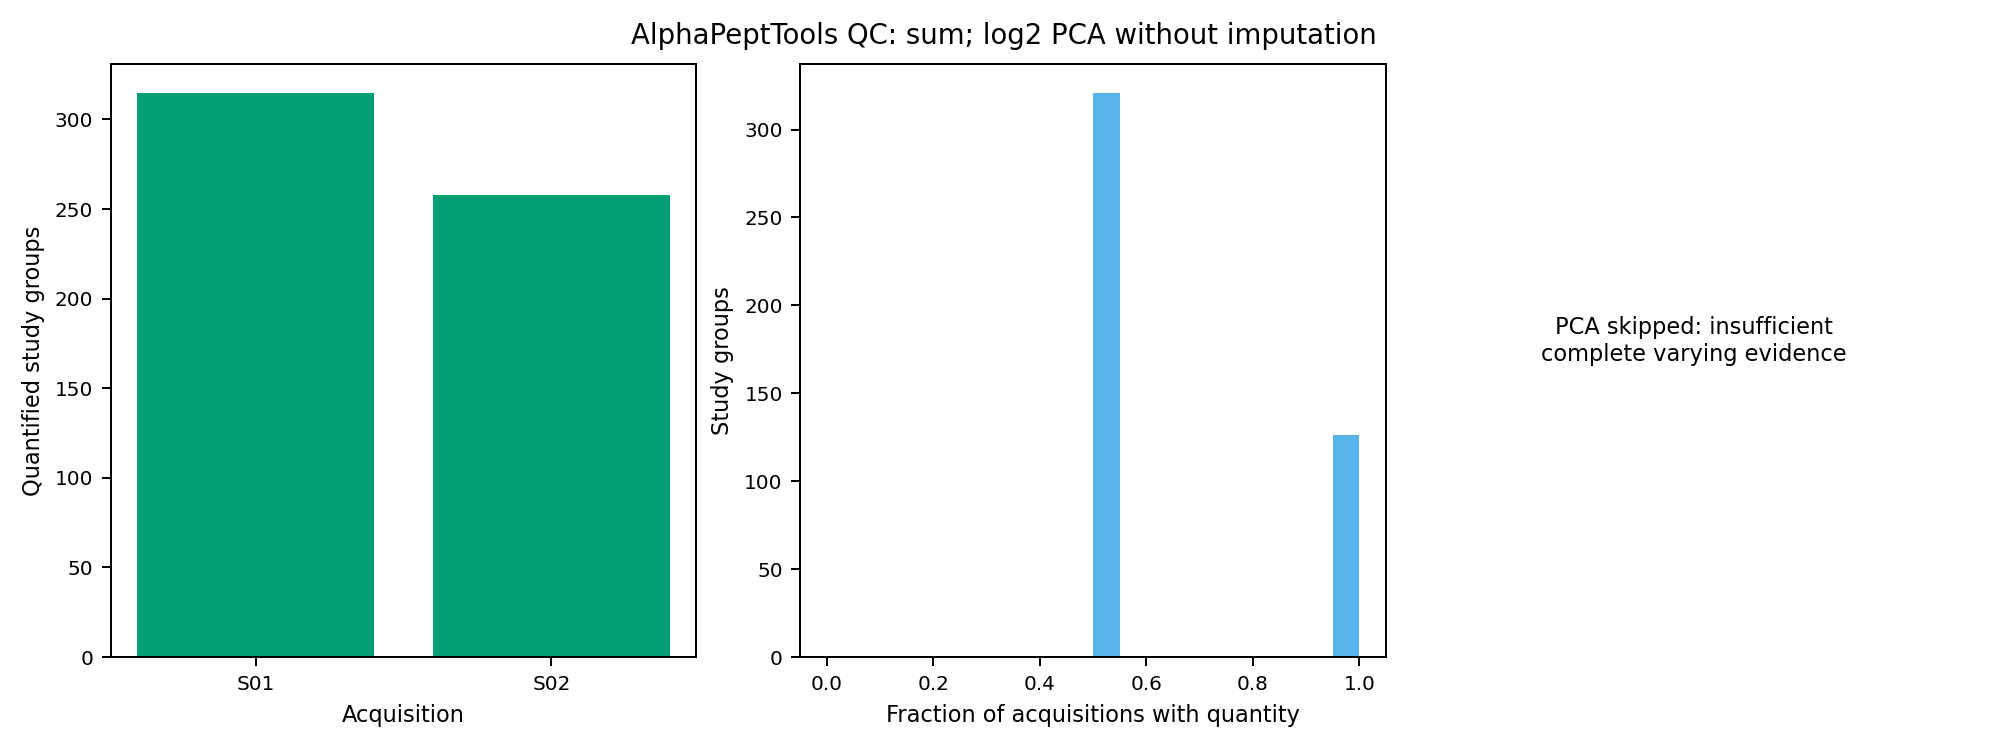

In [8]:
qc = json.loads((RUN / "study/qc/summary.json").read_text())
print(json.dumps(qc["pca"], indent=1)[:600])
from IPython.display import Image
Image(filename=str(RUN / "study/qc/QC_overview.png"), width=760)

## Provenance

`PROVENANCE.json` records every input hash and executable hash; `commands.json` records every stage with its return code and elapsed time. Together they are what makes two runs comparable.

In [9]:
commands = pd.DataFrame(json.loads((RUN / "workflow/commands.json").read_text()))
commands[[c for c in ("stage", "status", "returncode", "seconds") if c in commands.columns]]

,stage,seconds
0,evidence,0.160622
1,S01_extract,0.023672
2,S01_infer,0.023258
3,S01_search,1.715722
4,S02_extract,0.017280
5,S02_infer,0.027123
6,S02_search,1.648663
7,aggregate,0.021114
8,study_quantification,6.956056
